# About This Notebook:

This notebook investigates the animal intake information at the Albuqeurque City Animal Welfare department between the years of 2020 till July 2025 (the time of this report).

The aim is to understand the trends of the intakes, e.g. any increase or reduction, the most concentrated areas of pick ups, etc to see if any pattern emerges.




In this notebook:

<ol>
  <li><a href="#setup">Setup</a></li>
  <li><a href="#load.prelim">Load Data and Prelim Analysis</a></li>
    <ol>
      <li><a href="#vis">Visualization</a></li>
        <ol>
            <li><a href="#anim.type">Based on Animal Type</a></li>
            <li><a href="#outcome">Based on Outcome</a></li>
        </ol>
    </ol>
  <li><a href="#trends">Trends</a></li>
    <ol>            
        <li><a href="#out.rate">Outcome Rates</a></li>
         <li><a href="#out.rate.trend">Outcome Rates Trends</a></li>
    </ol>
    </ol>


<a id='setup'></a>
### 1. Setup

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

<a id='load.prelim'></a>

### 2. Load Data and Prelim Analysis

In [2]:
df = pd.read_csv('AnimalArrivalReport-2020-25.csv',
                 encoding='utf-16',
                 sep = '\t',
                 parse_dates= True,
                 on_bad_lines='skip')

In [3]:
df.head()

,Arrival Date,Animal Id,Animal Type,Intake Type,Sex,Years Old,Months Old,Primary Breed,Primary Color,Secondary Color,Where Picked Up,Outcome Type
0,2020-01-03 00:00:00,A1811429,BIRD,WILD,UNSPECIFIED,NaN,NaN,PIGEON,GRAY,NaN,8920 LOMAS,EUTHANASIA
1,2020-01-23 00:00:00,A1812205,BIRD,STRAY,FEMALE,1.0,NaN,CHICKEN,BROWN,NaN,528 BERNALILLO WALMART,ADOPTION
2,2020-01-29 00:00:00,A1812473,BIRD,CONFISCATE,FEMALE,1.0,NaN,CHICKEN,WHITE,NaN,804 CROMWELL AVE. SW,RECLAIM
3,2020-01-29 00:00:00,A1812474,BIRD,CONFISCATE,FEMALE,1.0,NaN,CHICKEN,WHITE,NaN,804 CROMWELL AVE. SW,RECLAIM
4,2020-01-29 00:00:00,A1812475,BIRD,CONFISCATE,FEMALE,1.0,NaN,CHICKEN,WHITE,NaN,804 CROMWELL AVE. SW,RECLAIM


In [4]:
df.shape

(96751, 12)

Let's check for `null` values and duplicates.

The `.info()` method below shows some null values in columns ['Years Old', 'Months Old','Primary Color', 'Secondary Color', 'Where Picked Up']. Let's quantify the missing values by using `.isnull().sum()` method.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96751 entries, 0 to 96750
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Arrival Date     96751 non-null  object 
 1   Animal Id        96751 non-null  object 
 2   Animal Type      96751 non-null  object 
 3   Intake Type      96751 non-null  object 
 4   Sex              96751 non-null  object 
 5   Years Old        42830 non-null  float64
 6   Months Old       45835 non-null  float64
 7   Primary Breed    96751 non-null  object 
 8   Primary Color    96745 non-null  object 
 9   Secondary Color  53186 non-null  object 
 10  Where Picked Up  76146 non-null  object 
 11  Outcome Type     96751 non-null  object 
dtypes: float64(2), object(10)
memory usage: 8.9+ MB


In [6]:
df.isnull().sum().sort_values(ascending = False)

Years Old          53921
Months Old         50916
Secondary Color    43565
Where Picked Up    20605
Primary Color          6
Arrival Date           0
Animal Id              0
Animal Type            0
Intake Type            0
Sex                    0
Primary Breed          0
Outcome Type           0
dtype: int64

It is possible that in cases when an animal is below 1 years old, only the `Months Old` column is filled and vise verca. Let's verify that. 

In [9]:
df_age_null = df[(df['Years Old'].isnull() & df['Months Old'].isnull())]

In [8]:
df_age_null.shape

(12402, 12)

I will drop these rows when analyzing based on age, but keeping for other analyses. 

<a id='vis'></a>
### 2.1. Visualization





In [258]:
# Ensure Arrival Date is datetime
df_dc['Arrival Date'] = pd.to_datetime(df_dc['Arrival Date'])

# Create a new column for year
df_dc['Arrival Year'] = df_dc['Arrival Date'].dt.year

# Group by year and animal type, and count
annual_counts = df_dc.groupby(['Arrival Year', 'Animal Type']).size().reset_index(name='Count')

# Optional: Sort for better readability
annual_counts = annual_counts.sort_values(by=['Arrival Year', 'Animal Type'])


In [259]:
annual_counts

,Arrival Year,Animal Type,Count
0,2020,CAT,4346
1,2020,DOG,7650
2,2021,CAT,7751
3,2021,DOG,9224
4,2022,CAT,8419
5,2022,DOG,9695
6,2023,CAT,9079
7,2023,DOG,10009
8,2024,CAT,7284
9,2024,DOG,10494


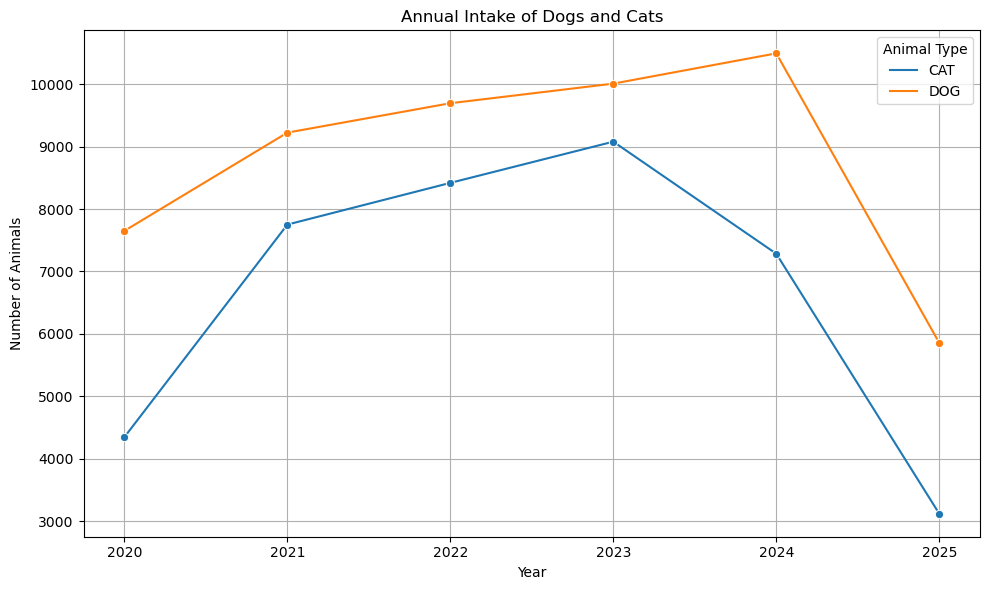

In [260]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=annual_counts, x='Arrival Year', y='Count', hue='Animal Type', marker='o')
plt.title('Annual Intake of Dogs and Cats')
plt.ylabel('Number of Animals')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


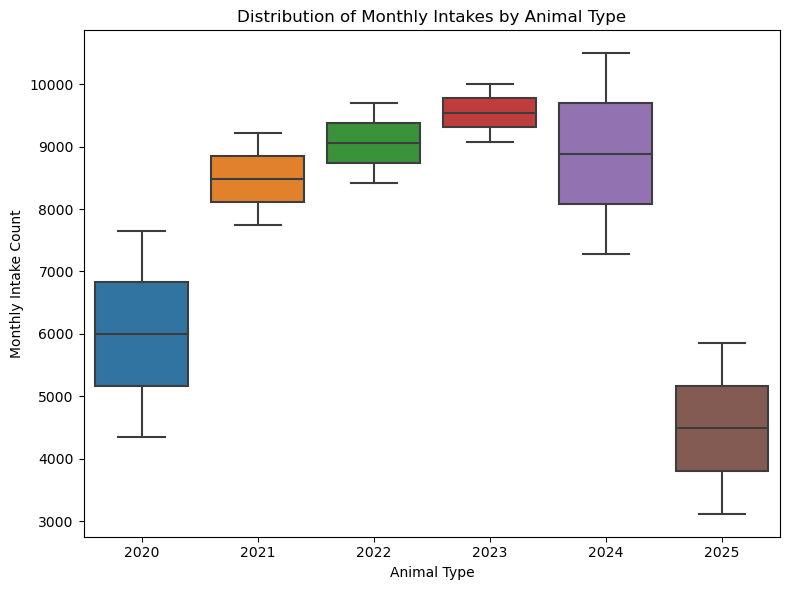

In [263]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=annual_counts, x= 'Arrival Year', y='Count')
plt.title('Distribution of Monthly Intakes by Animal Type')
plt.ylabel('Monthly Intake Count')
plt.xlabel('Animal Type')
plt.tight_layout()
plt.show()


Let's see what the distribution of animal types looks like. My guess is the "dog" category is going to have the highest concentration.

<a id='anim.type'></a>
#### 2.1.1. Based on Animal Type

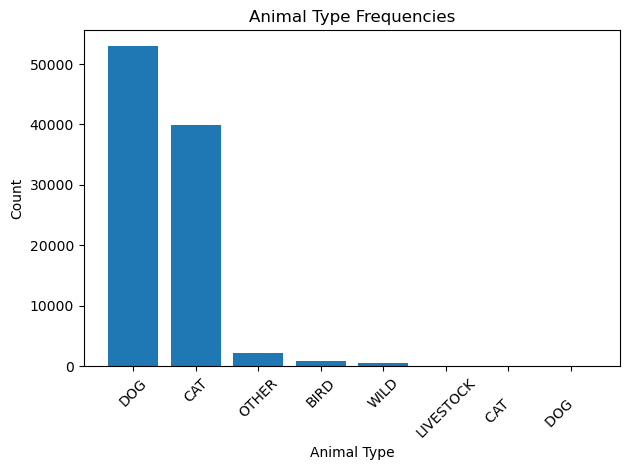

In [9]:
counts = df['Animal Type'].value_counts(ascending=False)  

plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.title('Animal Type Frequencies')
plt.xlabel('Animal Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


We see there is some spelling issues that need to be addressed. Let's check to see what issues there are:

In [10]:
df['Animal Type'].unique()

array(['BIRD', 'CAT', 'CAT       ', 'DOG', 'DOG       ', 'LIVESTOCK',
       'OTHER', 'WILD'], dtype=object)

Good. We have 1 spelling issue and that is white space after some animal categories. We can just strip the white space and hopefully consolidate the categories of the same type. 

In [11]:
df['Animal Type'] = df['Animal Type'].str.rstrip()

In [12]:
df['Animal Type'].unique()

array(['BIRD', 'CAT', 'DOG', 'LIVESTOCK', 'OTHER', 'WILD'], dtype=object)

Cool. We now have distinct categories without white space. Let's plot a histogram again to see the distribution of admitted animal types. 

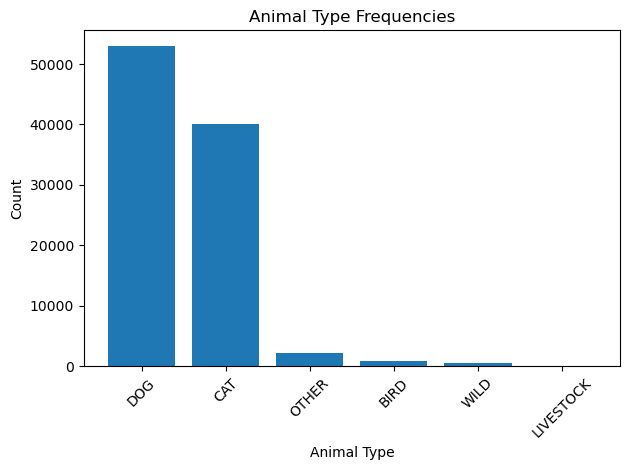

In [13]:
counts = df['Animal Type'].value_counts(ascending=False)  

plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.title('Animal Type Frequencies')
plt.xlabel('Animal Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


As expected, 'dog' has the highest percentage, followed by cat and then other animal types. 

In [14]:
df['Animal Type'].value_counts()


Animal Type
DOG          52927
CAT          39998
OTHER         2276
BIRD           893
WILD           602
LIVESTOCK       55
Name: count, dtype: int64

In [22]:
percent_dog = round(len(df[df['Animal Type'] == 'DOG']) / len(df) * 100, 2)
percent_cat = round(len(df[df['Animal Type'] == 'CAT']) / len(df) * 100, 2)

print('% of dogs: ', percent_dog)
print('% of cats: ', percent_cat)


% of dogs:  54.7
% of cats:  41.34


This leaves (100 - (54.7+ 41.34)) = 3.96% for all other animal types. I am going to drop those and focus on dogs and cats. I create a new dataframe `df_dc` that will only have those animal types.

In [16]:
df_dc = df[(df['Animal Type'] == 'DOG') | (df['Animal Type'] =='CAT')]

In [17]:
df_dc.head()

,Arrival Date,Animal Id,Animal Type,Intake Type,Sex,Years Old,Months Old,Primary Breed,Primary Color,Secondary Color,Where Picked Up,Outcome Type
893,2020-01-01 00:00:00,A1811359,CAT,STRAY,MALE,3.0,NaN,DOMESTIC LH,ORG TABBY,NaN,98TH / CENTRAL,ADOPTION
894,2020-01-01 00:00:00,A1811360,CAT,STRAY,MALE,3.0,NaN,DOMESTIC SH,BRN TABBY,WHITE,MONROE / ROMA,RECLAIM
895,2020-01-02 00:00:00,A1639097,CAT,STRAY,MALE,2.0,NaN,DOMESTIC MH,GRAY TAB,NaN,1104 SAN RAFAEL NE,RECLAIM
896,2020-01-02 00:00:00,A1767674,CAT,OWNER SUR,FEMALE,NaN,4.0,DOMESTIC MH,BLK SMOKE,NaN,NaN,RECLAIM
897,2020-01-02 00:00:00,A1780411,CAT,OWNER SUR,FEMALE,1.0,6.0,DOMESTIC SH,BUFF,NaN,NaN,ADOPTION


In [18]:
df_dc.shape

(92925, 12)

We don't need the 'Animal Id', so, let's drop it.

In [20]:
df_dc.drop(columns = ['Animal Id'], inplace = True)

<a id='outcome'></a>
#### 2.1.2. Based on Outcome

In [28]:
df_dc_grouped = df_dc.groupby(['Animal Type', 'Sex', 'Outcome Type']).size().reset_index(name='Count')


In [29]:
df_dc_grouped.head()

,Animal Type,Sex,Outcome Type,Count
0,CAT,FEMALE,ADOPTION,11383
1,CAT,FEMALE,DIED,313
2,CAT,FEMALE,DISPOSAL,11
3,CAT,FEMALE,EMERG EUTH,23
4,CAT,FEMALE,EUTHANASIA,744


Let's drop 'Unspecified' from the 'Sex' column.

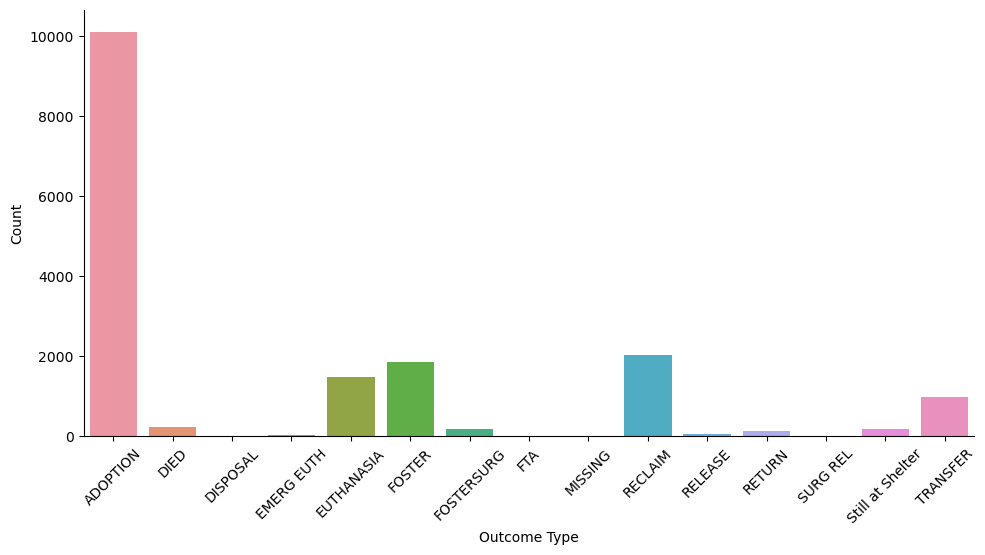

In [57]:
sns.catplot(data = df_dc_grouped, 
            x = 'Outcome Type',
            y = 'Count',
            kind = 'bar',
            ci = False,
            height=5,  
            aspect=2)

plt.xticks(rotation=45)
plt.show();

There are less common outcomes that are cluttering the plot, reducing its readability. Let's keep the most common 3 ones and the list for euthasia.

First, I group by the outcome type, and calculate the size/count of each outcome type. Then, show the count in descending order. Next, I use the series to filter the outcome types in my dataframe keeping top 3 and euthasia cases

In [51]:
df_dc_outcome = df_dc.groupby(['Outcome Type']).size().reset_index(name='Count')


In [52]:
total_outcomes = df_dc_outcome.groupby('Outcome Type')['Count'].sum().sort_values(ascending=False)
total_outcomes

Outcome Type
ADOPTION            50445
RECLAIM             12115
FOSTER              11118
EUTHANASIA           8863
TRANSFER             5890
DIED                 1404
Still at Shelter     1036
RETURN                764
FOSTERSURG            678
RELEASE               197
EMERG EUTH            159
MISSING               114
SURG REL               71
DISPOSAL               63
FTA                     8
Name: Count, dtype: int64

In [54]:
top_outcomes = total_outcomes.nlargest(3).index.tolist()
if 'EUTHANASIA' not in top_outcomes:
    top_outcomes.append('EUTHANASIA')

    
filtered = df_dc_outcome[df_dc_outcome['Outcome Type'].isin(top_outcomes)]

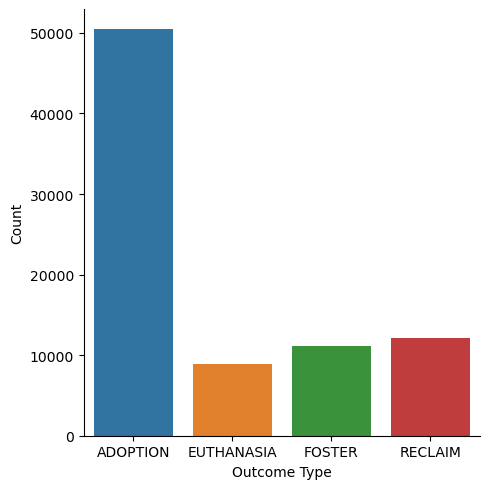

In [41]:
sns.catplot(data = filtered, 
            x = 'Outcome Type',
            y = 'Count',
            kind = 'bar',
            ci = False)
plt.show();

<a id='trends'></a>

### 3. Trends

Reminder what our dataframe including all the information (except Animal Id) for dogs and cats looks like:

In [58]:
df_dc.head()

,Arrival Date,Animal Type,Intake Type,Sex,Years Old,Months Old,Primary Breed,Primary Color,Secondary Color,Where Picked Up,Outcome Type
893,2020-01-01 00:00:00,CAT,STRAY,MALE,3.0,NaN,DOMESTIC LH,ORG TABBY,NaN,98TH / CENTRAL,ADOPTION
894,2020-01-01 00:00:00,CAT,STRAY,MALE,3.0,NaN,DOMESTIC SH,BRN TABBY,WHITE,MONROE / ROMA,RECLAIM
895,2020-01-02 00:00:00,CAT,STRAY,MALE,2.0,NaN,DOMESTIC MH,GRAY TAB,NaN,1104 SAN RAFAEL NE,RECLAIM
896,2020-01-02 00:00:00,CAT,OWNER SUR,FEMALE,NaN,4.0,DOMESTIC MH,BLK SMOKE,NaN,NaN,RECLAIM
897,2020-01-02 00:00:00,CAT,OWNER SUR,FEMALE,1.0,6.0,DOMESTIC SH,BUFF,NaN,NaN,ADOPTION


Let's change the 'Arrival Date' column to a less fine-grained time frame for easier plotting.

First, set the format of the column to datetime format. Then, create a new column with only year and month.

In [59]:
df_dc['Arrival Date'] = pd.to_datetime(df_dc['Arrival Date'])

df_dc['Arrival Year-Month'] = df_dc['Arrival Date'].dt.strftime('%Y-%m')


Now, define a new dataframe including the desired information, i.e. ['Arrival Year-Month','Animal Type','Outcome Type'].

In [60]:
df_dc_outcome_trend = df_dc.groupby(['Arrival Year-Month','Animal Type','Outcome Type']).size().reset_index(name='Count')

In [61]:
df_dc_outcome_trend.sort_values(by = 'Count', ascending = False)

,Arrival Year-Month,Animal Type,Outcome Type,Count
307,2021-07,CAT,ADOPTION,581
996,2024-07,CAT,ADOPTION,557
315,2021-07,DOG,ADOPTION,549
807,2023-10,CAT,ADOPTION,541
745,2023-07,CAT,ADOPTION,530
...,...,...,...,...
603,2022-11,CAT,RETURN,1
969,2024-05,DOG,FOSTERSURG,1
970,2024-05,DOG,MISSING,1
973,2024-05,DOG,Still at Shelter,1


Keeping the 3 most possible outcomes (for plotting purposes) and 'Euthanasia' ones.

In [64]:
df_dc_outcome_trend_filtered = df_dc_outcome_trend[df_dc_outcome_trend['Outcome Type'].isin(top_outcomes)]

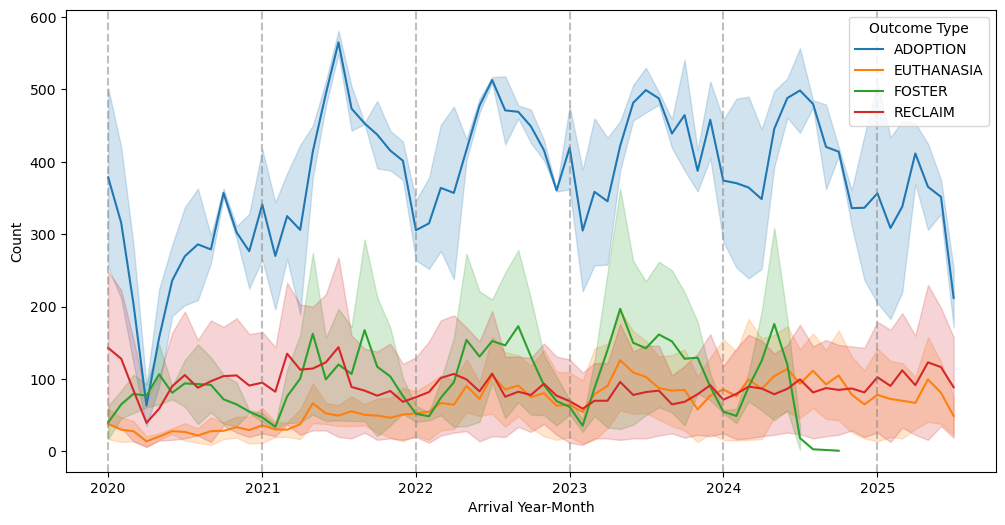

In [65]:
df_dc_outcome_trend_filtered['Arrival Year-Month'] = pd.to_datetime(df_dc_outcome_trend_filtered['Arrival Year-Month'])


plt.figure(figsize=(12,6))
sns.lineplot(data=df_dc_outcome_trend_filtered, x='Arrival Year-Month', y='Count', hue='Outcome Type')

# Get unique years in the data
years = df_dc_outcome_trend_filtered['Arrival Year-Month'].dt.year.unique()

# For each year, find the first date of that year present in the data to add a vertical line
for year in years:
    year_start = pd.Timestamp(f'{year}-01-01')
    plt.axvline(x=year_start, color='gray', linestyle='--', alpha=0.5)


The above plot shows the outcome for both dogs and cats, and we can see that the 95% confidence interval is pretty big. Let's separate the outcomes for these two groups and plot them individually.

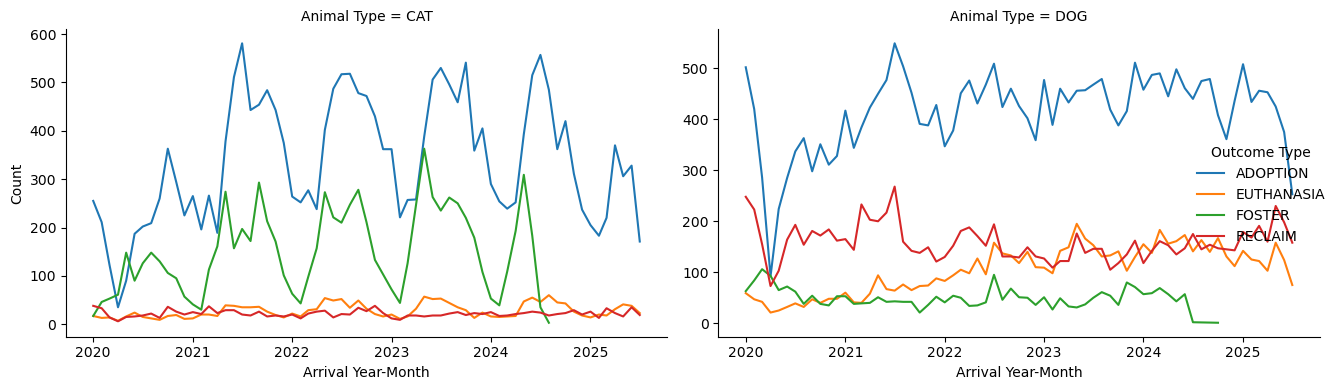

In [69]:
sns.relplot(
    data=df_dc_outcome_trend_filtered,
    x='Arrival Year-Month',
    y='Count',
    hue='Outcome Type',
    kind='line',
    col='Animal Type',
    col_wrap=2,  
    height=4,
    aspect=1.5,
    facet_kws={'sharey': False}  
)


plt.tight_layout()
plt.show()


General observation shows some seasonality for cats, with adoption and foster trends having dips and rises. The trens for reclaim and euthanasia are pretty flat. 

The seasonality for dogs is not as pronounced.  While the reclaim and foster rates are pretty much flat, we can see an upward trajectory in the euthanasia line.

To do a more detailed analysis, I separate the data to two sets, one for dogs and one for cats.

In [79]:
df_cats = df_dc_outcome_trend_filtered[df_dc_outcome_trend_filtered['Animal Type'] == 'CAT']
df_cats['Arrival Year-Month'] = pd.to_datetime(df_cats['Arrival Year-Month'])


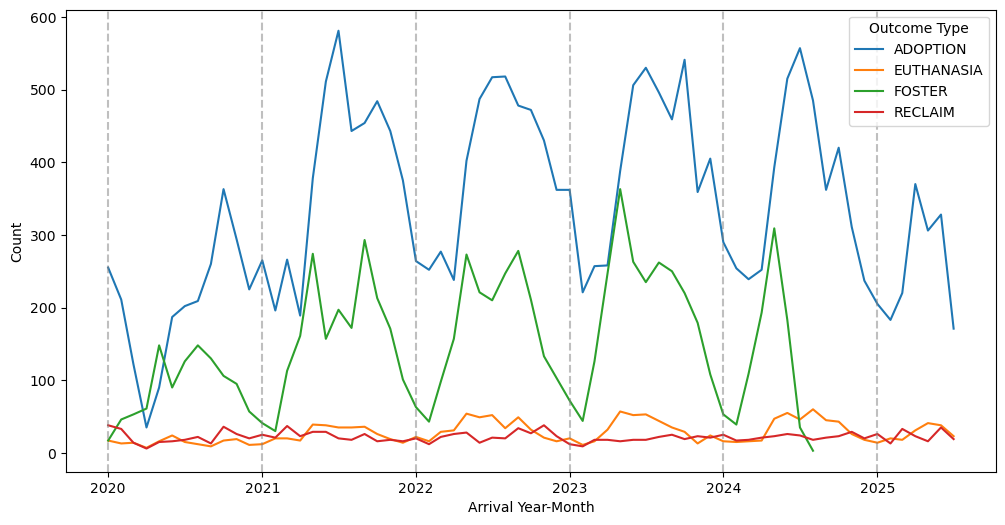

In [80]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_cats, x='Arrival Year-Month', y='Count', hue='Outcome Type')

years = df_cats['Arrival Year-Month'].dt.year.unique()

for year in years:
    year_start = pd.Timestamp(f'{year}-01-01')
    plt.axvline(x=year_start, color='gray', linestyle='--', alpha=0.5)


We can see the jump in the adoption rate almost at mid-year for every year since 2020. The same goes for foster rate. Note we are in middle of the year 2025, and missing 5 months worth of data. 

The euthanasia rate is pretty flat. 

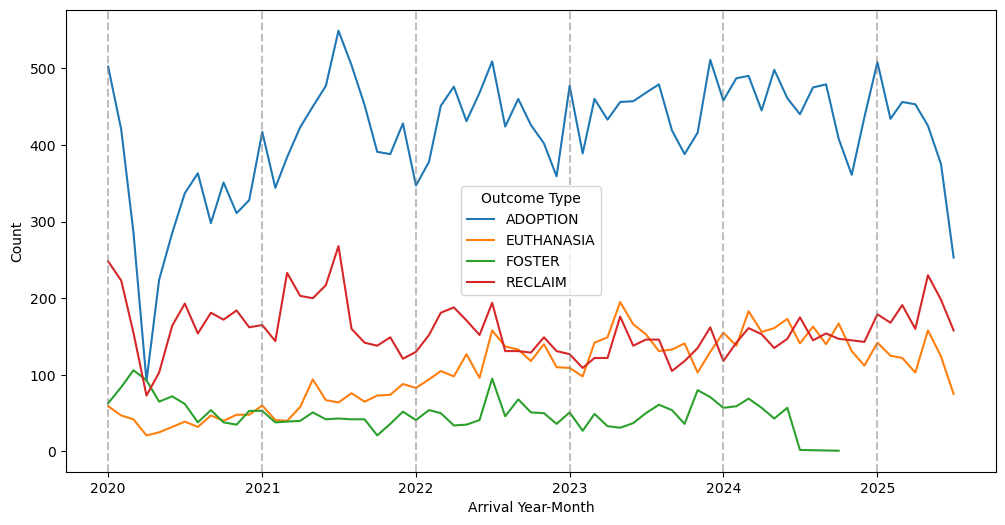

In [81]:
df_dogs = df_dc_outcome_trend_filtered[df_dc_outcome_trend_filtered['Animal Type'] == 'DOG']

df_dogs['Arrival Year-Month'] = pd.to_datetime(df_dogs['Arrival Year-Month'])


plt.figure(figsize=(12,6))
sns.lineplot(data=df_dogs, x='Arrival Year-Month', y='Count', hue='Outcome Type')

years = df_dogs['Arrival Year-Month'].dt.year.unique()

for year in years:
    year_start = pd.Timestamp(f'{year}-01-01')
    plt.axvline(x=year_start, color='gray', linestyle='--', alpha=0.5)


This plot shows more clearly the upward trend of euthanasia rate in dogs. Below, I quantify the rates of outcomes for cats and dogs.

<a id='out.rate'></a>

#### 3.1. Outcome Rates

In [82]:
cats_outcomes = df_cats.groupby('Outcome Type')['Count'].sum().sort_values(ascending=False)
print(cats_outcomes)


Outcome Type
ADOPTION      22615
FOSTER         8330
EUTHANASIA     1865
RECLAIM        1469
Name: Count, dtype: int64


In [83]:
cats_outcomes[0]

22615

In [84]:
print('Adoption % in Cats: ', round(cats_outcomes[0]/ sum(cats_outcomes) *100,2))
print('Reclaim % in Cats: ', round(cats_outcomes[1]/ sum(cats_outcomes) *100,2))
print('Euthanasia % in Cats: ', round(cats_outcomes[2]/ sum(cats_outcomes) *100,2))
print('Foster % in Cats: ', round(cats_outcomes[3]/ sum(cats_outcomes) *100,2))


Adoption % in Cats:  65.97
Reclaim % in Cats:  24.3
Euthanasia % in Cats:  5.44
Foster % in Cats:  4.29


In [85]:
dogs_outcomes = df_dogs.groupby('Outcome Type')['Count'].sum().sort_values(ascending=False)
print(dogs_outcomes)

Outcome Type
ADOPTION      27830
RECLAIM       10646
EUTHANASIA     6998
FOSTER         2788
Name: Count, dtype: int64


In [86]:
print('Adoption % in Dogs: ', round(dogs_outcomes[0]/ sum(dogs_outcomes) *100,2))
print('Reclaim % in Dogs: ', round(dogs_outcomes[1]/ sum(dogs_outcomes) *100,2))
print('Euthanasia % in Dogs: ', round(dogs_outcomes[2]/ sum(dogs_outcomes) *100,2))
print('Foster % in Dogs: ', round(dogs_outcomes[3]/ sum(dogs_outcomes) *100,2))

Adoption % in Dogs:  57.66
Reclaim % in Dogs:  22.06
Euthanasia % in Dogs:  14.5
Foster % in Dogs:  5.78


<a id='out.rate.trend'></a>

#### 3.1.1 Outcome Rates Trends

Starting with dogs, first, I extract the year information from the 'Arrival Year-Month' column assigning it to a new column 'Year'.

Then, I use the `.groupby()` method to group the outcome types by year based on their count.

In [132]:
df_dogs['Year'] = pd.to_datetime(df_dogs['Arrival Year-Month']).dt.year
df_dogs_grouped = df_dogs.groupby(['Year', 'Outcome Type']).size().reset_index(name='Count')

Now, I need to calculate the euthanasia percentage/rate for each year. I achieve that by writing a `for` loop over years and outcomes, extracting their relevant numbers and then calculating the percentage based on that.

In [142]:
outcomes = df_dogs_grouped['Outcome Type'].to_list()
years = df_dogs_grouped['Year'].unique()

In [162]:
percent_euth = {}
for year in years:
    rates_all = df_dogs_grouped[df_dogs_grouped['Year'] == year].Count.sum()
    rates_euth = df_dogs_grouped[(df_dogs_grouped['Year'] == year) & (df_dogs_grouped['Outcome Type'] =='EUTHANASIA')].Count.sum()        
    percent_euth[year] =    rates_euth/rates_all *100
        

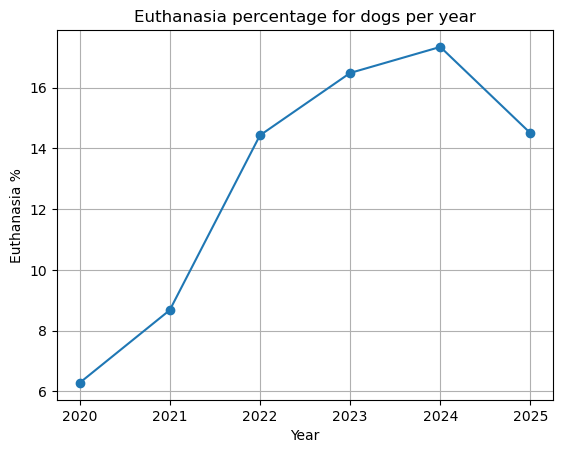

In [171]:
plt.plot(percent_euth.keys(), percent_euth.values(), marker = 'o')
plt.xlabel('Year')
plt.ylabel('Euthanasia %')
plt.title('Euthanasia percentage for dogs per year')
plt.grid()
plt.show();

We see a consistent increase in the rate of euthanised dogs. Note the data for 2025 is up to July and missing 5 months. This means the rate 2025 will be higher than shown now by the end of the year.

Let's do the same for cats.

In [172]:
df_cats['Year'] = pd.to_datetime(df_cats['Arrival Year-Month']).dt.year
df_cats_grouped = df_cats.groupby(['Year', 'Outcome Type']).size().reset_index(name='Count')

In [173]:
# running again in case there is inconsistency between the two groups
outcomes = df_cats_grouped['Outcome Type'].to_list()
years = df_cats_grouped['Year'].unique()

In [174]:
percent_euth_cats = {}
for year in years:
    rates_all = df_cats_grouped[df_cats_grouped['Year'] == year].Count.sum()
    rates_euth = df_cats_grouped[(df_cats_grouped['Year'] == year) & (df_cats_grouped['Outcome Type'] =='EUTHANASIA')].Count.sum()        
    percent_euth_cats[year] =    rates_euth/rates_all *100

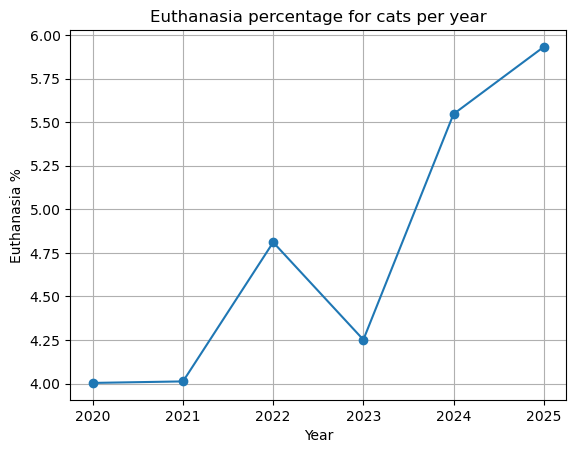

In [175]:
plt.plot(percent_euth_cats.keys(), percent_euth_cats.values(), marker = 'o')
plt.xlabel('Year')
plt.ylabel('Euthanasia %')
plt.title('Euthanasia percentage for cats per year')
plt.grid()
plt.show();